In [1]:
# ============================================================
# PROJET 4 — ANALYSE FINANCIÈRE & MARCHÉS BOURSIERS
# ============================================================
# Objectif : analyser un portefeuille mixte (international + africain)
# Concepts : log-returns, rolling stats, corrélation, Sharpe ratio, volatilité
# Stack    : yfinance, Pandas, Plotly
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

print("✅ Imports OK !")

✅ Imports OK !


In [3]:
# ============================================================
# ÉTAPE 1 — DÉFINITION DU PORTEFEUILLE & TÉLÉCHARGEMENT (corrigé)
# ============================================================

tickers = {
    'AAPL': 'Apple',
    'MSFT': 'Microsoft', 
    'TSLA': 'Tesla',
    'EZA': 'ETF Afrique du Sud',
    'NPN.JO': 'Naspers (JSE)'
}

data = {}
erreurs = []

for symbole, nom in tickers.items():
    try:
        hist = yf.download(symbole, start='2022-01-01', end='2024-12-31', progress=False)
        
        if hist.empty:
            erreurs.append(symbole)
            print(f"⚠️ {nom} ({symbole}) : aucune donnée reçue")
            continue
        
        # Extraire la colonne Close proprement, peu importe la structure des colonnes
        close = hist['Close']
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]  # Garde la première colonne si structure imbriquée
        
        data[symbole] = close
        print(f"✅ {nom} ({symbole}) : {len(close)} jours téléchargés")
        
    except Exception as e:
        erreurs.append(symbole)
        print(f"❌ {nom} ({symbole}) : erreur - {e}")

# Combiner tout dans un seul DataFrame
prix = pd.DataFrame(data)
print(f"\n📊 Actifs récupérés avec succès : {list(prix.columns)}")
if erreurs:
    print(f"⚠️ Actifs en échec (ignorés) : {erreurs}")

prix.head()

✅ Apple (AAPL) : 752 jours téléchargés
✅ Microsoft (MSFT) : 752 jours téléchargés
✅ Tesla (TSLA) : 752 jours téléchargés
✅ ETF Afrique du Sud (EZA) : 752 jours téléchargés
✅ Naspers (JSE) (NPN.JO) : 747 jours téléchargés

📊 Actifs récupérés avec succès : ['AAPL', 'MSFT', 'TSLA', 'EZA', 'NPN.JO']


,AAPL,MSFT,TSLA,EZA,NPN.JO
Date,,,,,
2022-01-03,177.786392,321.856445,399.926666,37.801605,50223.875000
2022-01-04,175.529984,316.337616,383.196655,37.608902,51443.316406
2022-01-05,170.860886,304.193939,362.706665,37.624966,49665.351562
2022-01-06,168.008682,301.790253,354.899994,37.881897,47899.578125
2022-01-07,168.174728,301.944183,342.320007,37.986279,47774.597656


In [5]:
# ============================================================
# ÉTAPE 2 — VÉRIFICATION DES VALEURS MANQUANTES
# ============================================================

print(" Valeurs manquantes par actif :\n")
print(prix.isnull().sum())

# Remplir les jours fériés différents par la dernière valeur connue
prix = prix.ffill().dropna()

print(f"\n✅ Après nettoyage : {len(prix)} jours, {prix.isnull().sum().sum()} valeurs manquantes restantes")
prix.describe()

 Valeurs manquantes par actif :

AAPL      0
MSFT      0
TSLA      0
EZA       0
NPN.JO    0
dtype: int64

✅ Après nettoyage : 773 jours, 0 valeurs manquantes restantes


,AAPL,MSFT,TSLA,EZA,NPN.JO
count,773.000000,773.000000,773.000000,773.000000,773.000000
mean,175.623798,326.383081,236.768780,36.272722,60489.560582
std,29.339049,70.672951,60.678574,3.646963,14289.467432
min,122.827614,207.343643,108.099998,29.502300,28540.093750
25%,152.839081,262.549011,190.410004,33.482533,49882.714844
50%,170.887085,317.915009,233.070007,35.418243,63655.144531
75%,189.236115,402.107880,267.429993,38.502045,68715.796875
max,257.153809,459.460663,479.859985,45.349079,88907.117188


In [6]:
# ============================================================
# ÉTAPE 3 — LOG-RETURNS (RENDEMENTS LOGARITHMIQUES)
# ============================================================

log_returns = np.log(prix / prix.shift(1)).dropna()

print("📊 Aperçu des log-returns (rendements quotidiens) :\n")
print(log_returns.head())

print("\n📊 Statistiques des rendements :\n")
print(log_returns.describe().round(4))

📊 Aperçu des log-returns (rendements quotidiens) :

                AAPL      MSFT      TSLA       EZA    NPN.JO
Date                                                        
2022-01-04 -0.012773 -0.017296 -0.042733 -0.005111  0.023990
2022-01-05 -0.026960 -0.039145 -0.054954  0.000427 -0.035173
2022-01-06 -0.016834 -0.007933 -0.021758  0.006806 -0.036201
2022-01-07  0.000988  0.000510 -0.036090  0.002752 -0.002613
2022-01-10  0.000116  0.000732  0.029891  0.008838 -0.006256

📊 Statistiques des rendements :

           AAPL      MSFT      TSLA       EZA    NPN.JO
count  772.0000  772.0000  772.0000  772.0000  772.0000
mean     0.0004    0.0003    0.0001    0.0000    0.0007
std      0.0168    0.0171    0.0380    0.0177    0.0290
min     -0.0605   -0.0803   -0.1316   -0.0620   -0.1948
25%     -0.0082   -0.0082   -0.0203   -0.0109   -0.0138
50%      0.0006    0.0002    0.0000    0.0000    0.0000
75%      0.0094    0.0104    0.0203    0.0100    0.0127
max      0.0852    0.0791    0.1982    

📊 Aperçu de la volatilité glissante annualisée :

                AAPL      MSFT      TSLA       EZA    NPN.JO
Date                                                        
2024-12-23  0.135872  0.192223  0.597204  0.215296  0.211359
2024-12-24  0.136741  0.191128  0.586615  0.212103  0.211874
2024-12-26  0.136798  0.191138  0.592485  0.209529  0.211125
2024-12-27  0.143582  0.198260  0.584018  0.209523  0.210235
2024-12-30  0.142667  0.183743  0.594859  0.213237  0.219981


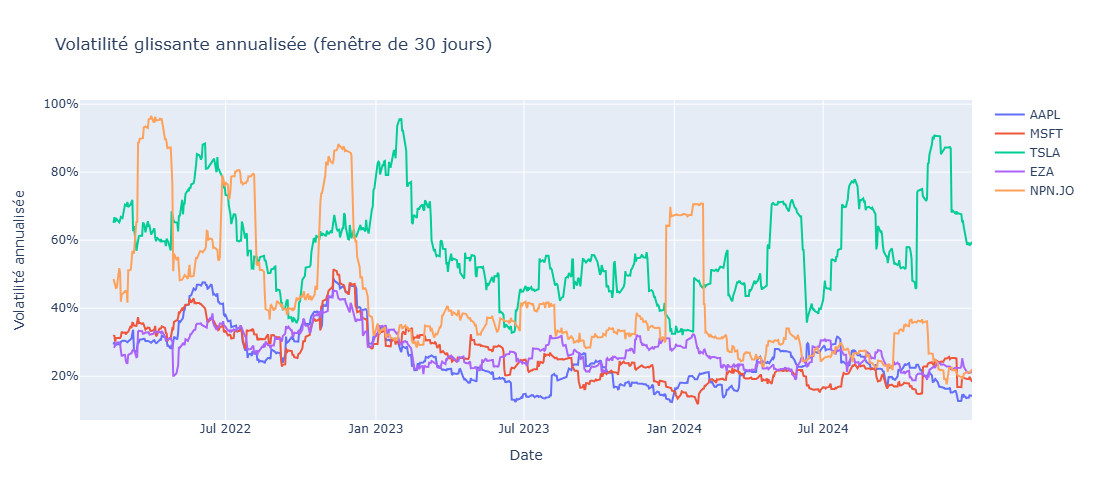

In [7]:
# ============================================================
# ÉTAPE 4 — ROLLING STATS : VOLATILITÉ GLISSANTE (30 JOURS)
# ============================================================

# Volatilité glissante sur 30 jours, annualisée
volatilite_glissante = log_returns.rolling(window=30).std() * np.sqrt(252)

print("📊 Aperçu de la volatilité glissante annualisée :\n")
print(volatilite_glissante.tail())

fig = go.Figure()

for colonne in volatilite_glissante.columns:
    fig.add_trace(go.Scatter(
        x=volatilite_glissante.index,
        y=volatilite_glissante[colonne],
        mode='lines',
        name=colonne
    ))

fig.update_layout(
    title="Volatilité glissante annualisée (fenêtre de 30 jours)",
    xaxis_title="Date",
    yaxis_title="Volatilité annualisée",
    yaxis_tickformat=".0%",
    hovermode='x unified',
    height=500
)

fig.show()

📊 Matrice de corrélation des rendements :

        AAPL  MSFT  TSLA   EZA  NPN.JO
AAPL    1.00  0.69  0.50  0.40    0.17
MSFT    0.69  1.00  0.42  0.36    0.16
TSLA    0.50  0.42  1.00  0.31    0.19
EZA     0.40  0.36  0.31  1.00    0.38
NPN.JO  0.17  0.16  0.19  0.38    1.00


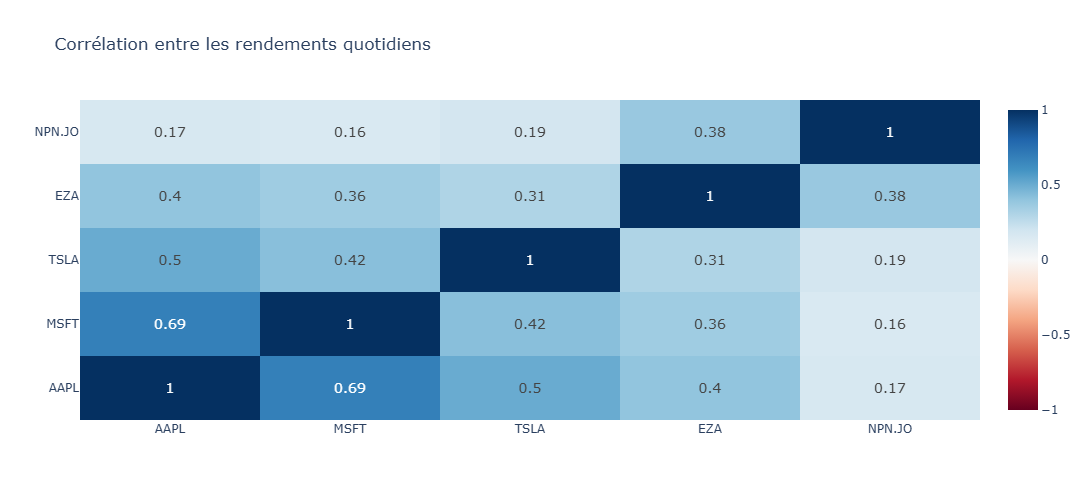

In [8]:
# ============================================================
# ÉTAPE 5 — MATRICE DE CORRÉLATION
# ============================================================

correlation = log_returns.corr()

print("📊 Matrice de corrélation des rendements :\n")
print(correlation.round(2))

fig = go.Figure(data=go.Heatmap(
    z=correlation.values,
    x=correlation.columns,
    y=correlation.columns,
    colorscale='RdBu',
    zmid=0,
    text=correlation.round(2).values,
    texttemplate="%{text}",
    textfont={"size": 14}
))

fig.update_layout(
    title="Corrélation entre les rendements quotidiens",
    height=500,
    width=600
)

fig.show()

In [9]:
# ============================================================
# ÉTAPE 6 — SHARPE RATIO
# ============================================================

# Taux sans risque approximatif (bons du Trésor US ~4% par an en 2022-2024)
taux_sans_risque = 0.04

rendement_annuel = log_returns.mean() * 252
volatilite_annuelle = log_returns.std() * np.sqrt(252)

sharpe_ratio = (rendement_annuel - taux_sans_risque) / volatilite_annuelle

resume = pd.DataFrame({
    'Rendement annuel': rendement_annuel,
    'Volatilité annuelle': volatilite_annuelle,
    'Sharpe Ratio': sharpe_ratio
}).round(3)

resume = resume.sort_values('Sharpe Ratio', ascending=False)

print("📊 Résumé risque/rendement par actif :\n")
print(resume)

📊 Résumé risque/rendement par actif :

        Rendement annuel  Volatilité annuelle  Sharpe Ratio
AAPL               0.112                0.267         0.269
NPN.JO             0.164                0.461         0.269
MSFT               0.086                0.272         0.170
TSLA               0.014                0.603        -0.043
EZA                0.007                0.281        -0.117


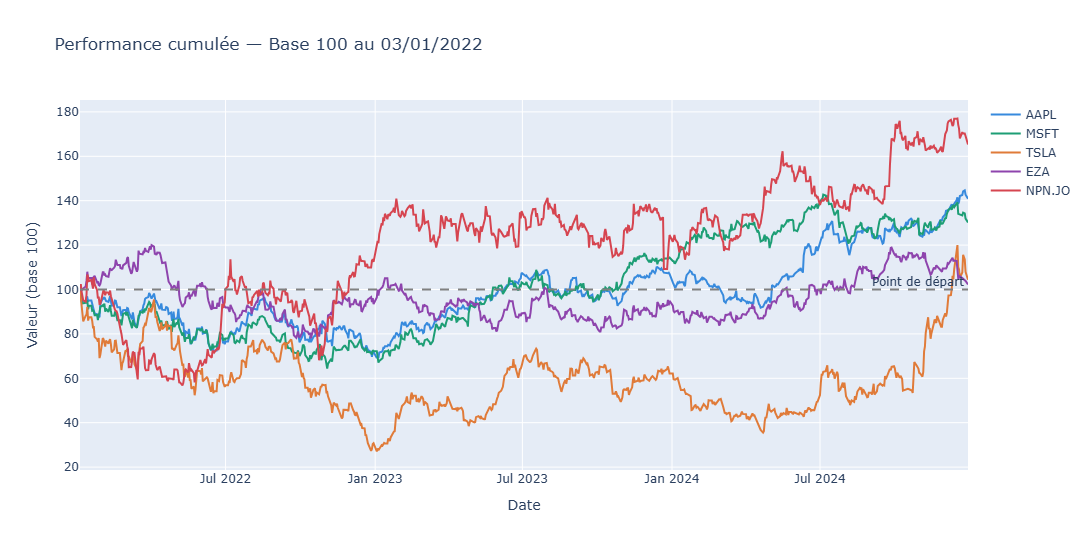

📊 Performance finale (base 100) :

NPN.JO    165.3
AAPL      140.8
MSFT      130.2
TSLA      104.4
EZA       102.2
Name: 2024-12-30 00:00:00, dtype: float64


In [10]:
# ============================================================
# ÉTAPE 7 — PERFORMANCE CUMULÉE (base 100)
# ============================================================

# Convertir chaque actif en indice base 100 au départ
performance_cumulee = (prix / prix.iloc[0]) * 100

fig = go.Figure()

couleurs = {
    'AAPL': '#378ADD', 'MSFT': '#1D9E75', 
    'TSLA': '#E07B39', 'EZA': '#8E44AD', 'NPN.JO': '#D64550'
}

for colonne in performance_cumulee.columns:
    fig.add_trace(go.Scatter(
        x=performance_cumulee.index,
        y=performance_cumulee[colonne],
        mode='lines',
        name=colonne,
        line=dict(color=couleurs.get(colonne, '#333'), width=2)
    ))

fig.add_hline(y=100, line_dash="dash", line_color="gray", 
              annotation_text="Point de départ")

fig.update_layout(
    title="Performance cumulée — Base 100 au 03/01/2022",
    xaxis_title="Date",
    yaxis_title="Valeur (base 100)",
    hovermode='x unified',
    height=550
)

fig.show()

# --- Résumé final ---
performance_finale = performance_cumulee.iloc[-1].sort_values(ascending=False)
print("📊 Performance finale (base 100) :\n")
print(performance_finale.round(1))